In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/clean_data.csv")
print("Nombre d'annonces:", len(df))

Nombre d'annonces: 3102


In [4]:
df_public = df[
    [
        "prix",
        "surface",
        "chambres",
        "salles_de_bain",
        "etage",
        "localisation",
        "prix_par_m2",
        "categorie_prix",
        "categorie_surface",
        "type_etage"
    ]
]

In [6]:
df_public.head()

,prix,surface,chambres,salles_de_bain,etage,localisation,prix_par_m2,categorie_prix,categorie_surface,type_etage
0,190000.0,55.0,2.0,1.0,2.0,"salé, toute la ville",3454.545455,Tres bas,Petit,Bas
1,2370000.0,145.0,2.0,2.0,2.0,"dar bouazza, toute la ville",16344.827586,Eleve,Grand,Bas
2,360000.0,50.0,2.0,1.0,2.0,"dar bouazza, toute la ville",7200.000000,Tres bas,Studio,Bas
3,650000.0,84.0,2.0,1.0,1.0,"marrakech, mabrouka",7738.095238,Bas,Moyen,Bas
4,800000.0,92.0,2.0,1.0,2.0,"tanger, val fleuri",8695.652174,Bas,Moyen,Bas


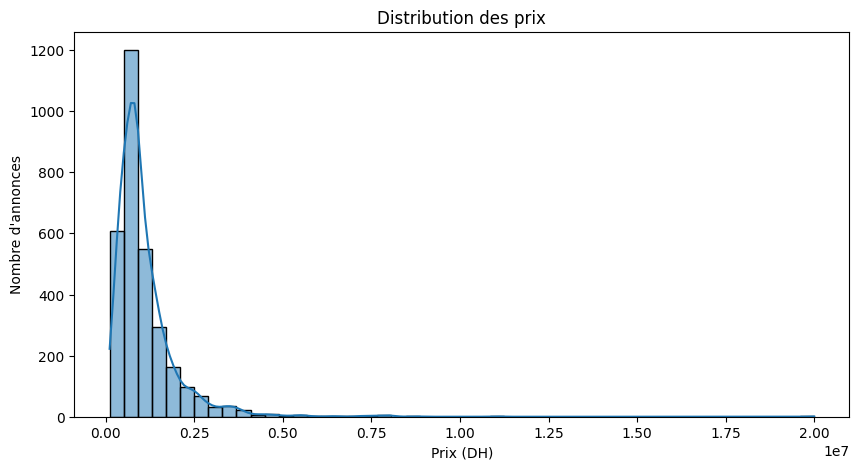

In [4]:
#Distribution des prix
plt.figure(figsize=(10, 5))
sns.histplot(df["prix"], bins=50, kde=True)
plt.title("Distribution des prix")
plt.xlabel("Prix (DH)")
plt.ylabel("Nombre d'annonces")
plt.show()

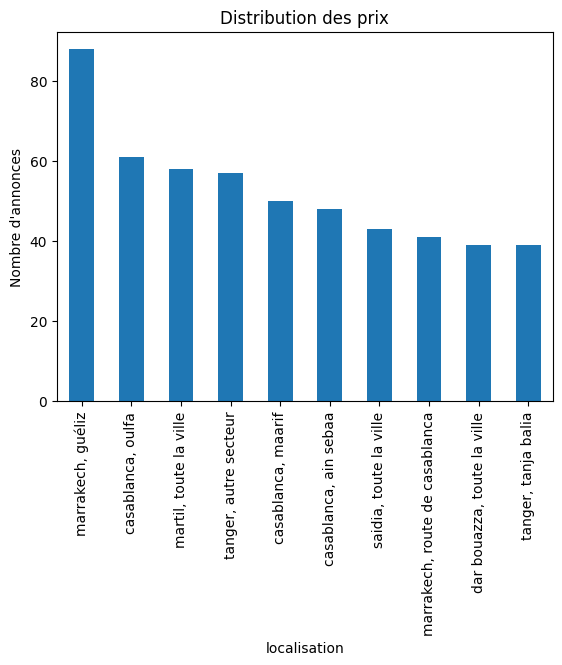

In [5]:
df["localisation"].value_counts().head(10).plot(kind="bar")
plt.title("Distribution des prix")
plt.ylabel("Nombre d'annonces")
plt.show()

In [6]:
df["ville"] = df["localisation"].str.split(",").str[0].str.strip()
print(df["ville"].value_counts().head(10))

ville
casablanca    799
marrakech     404
tanger        300
kénitra       169
agadir        136
temara        111
meknès        101
mohammedia     97
rabat          94
salé           90
Name: count, dtype: int64


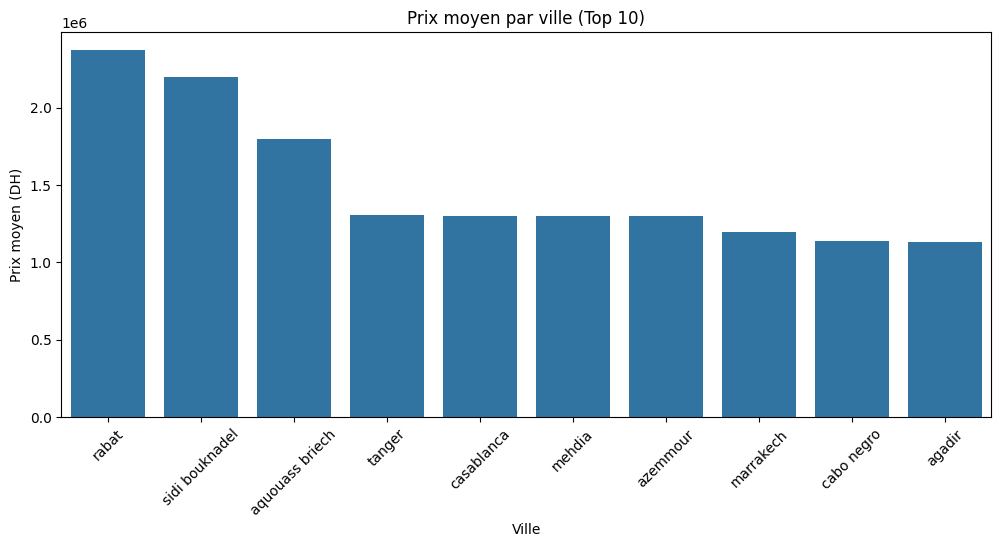

In [7]:
# Prix moyen par ville
ville_prix = df.groupby("ville")["prix"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=ville_prix.index, y=ville_prix.values)
plt.title("Prix moyen par ville (Top 10)")
plt.xlabel("Ville")
plt.ylabel("Prix moyen (DH)")
plt.xticks(rotation=45)
plt.show()

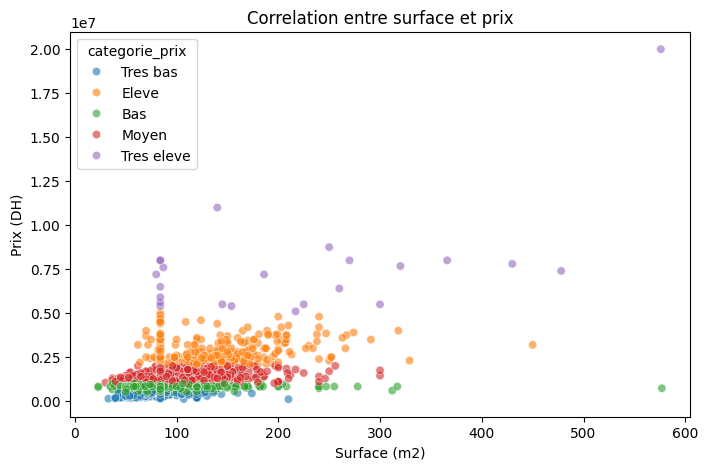

In [8]:
#Correlation entre prix et surface
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="surface", y="prix", hue="categorie_prix", alpha=0.6)
plt.title("Correlation entre surface et prix")
plt.xlabel("Surface (m2)")
plt.ylabel("Prix (DH)")
plt.show()

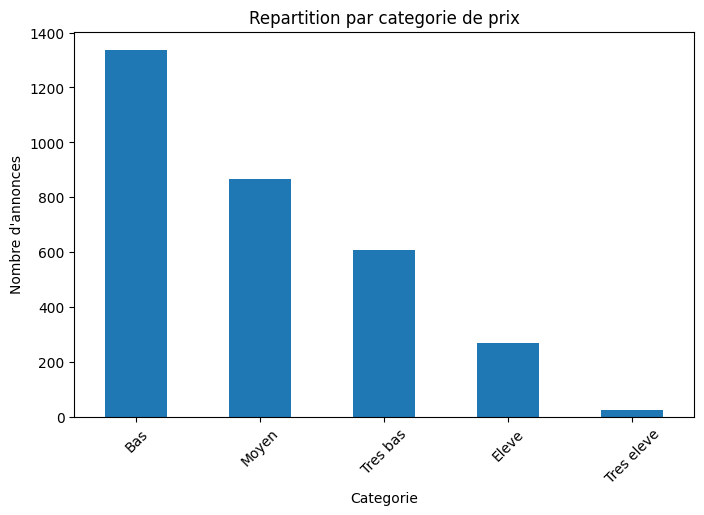

In [9]:
#Repartition par categorie de prix
plt.figure(figsize=(8, 5))
df["categorie_prix"].value_counts().plot(kind="bar")
plt.title("Repartition par categorie de prix")
plt.xlabel("Categorie")
plt.ylabel("Nombre d'annonces")
plt.xticks(rotation=45)
plt.show()

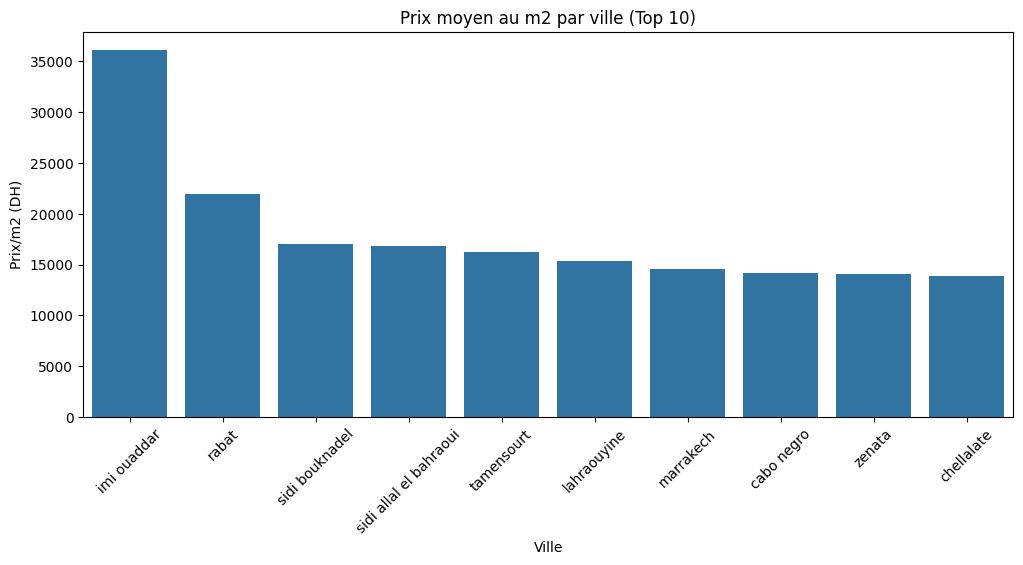

In [10]:
#Prix au m2 par ville
ville_m2 = df.groupby("ville")["prix_par_m2"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=ville_m2.index, y=ville_m2.values)
plt.title("Prix moyen au m2 par ville (Top 10)")
plt.xlabel("Ville")
plt.ylabel("Prix/m2 (DH)")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='prix', ylabel='Count'>

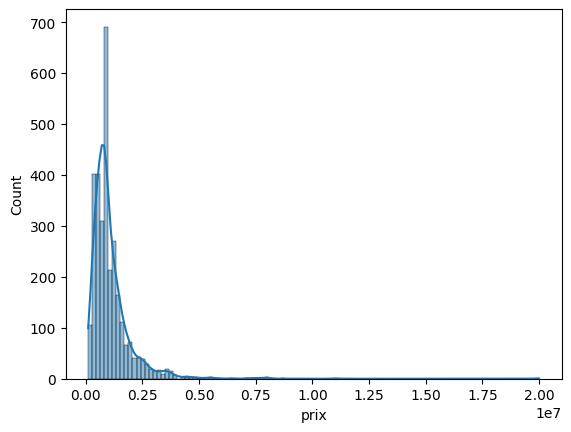

In [11]:
#Distribution du prix
sns.histplot(df["prix"], kde=True)

<Axes: xlabel='surface', ylabel='prix'>

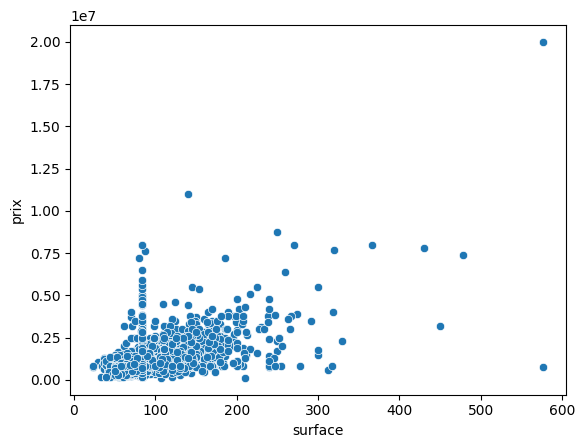

In [12]:
#Surface vs Prix
sns.scatterplot(data=df, x="surface", y="prix")

<Axes: >

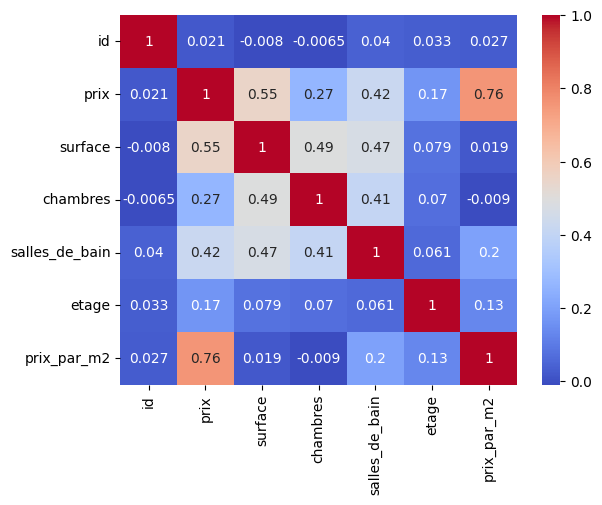

In [13]:
#Matrice de corrélation
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

In [14]:
len(df)

3102

In [16]:
print(df.shape[1])

17


In [17]:
print(df['ville'].nunique())

91


In [18]:
print(df.columns.tolist())

['id', 'titre', 'prix', 'surface', 'chambres', 'salles_de_bain', 'etage', 'localisation', 'vendeur', 'type_vendeur', 'date', 'lien', 'prix_par_m2', 'categorie_prix', 'categorie_surface', 'type_etage', 'ville']


In [20]:
df.columns

Index(['id', 'titre', 'prix', 'surface', 'chambres', 'salles_de_bain', 'etage',
       'localisation', 'vendeur', 'type_vendeur', 'date', 'lien',
       'prix_par_m2', 'categorie_prix', 'categorie_surface', 'type_etage',
       'ville'],
      dtype='object')